# Complexity Metrics Smoke Test

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for p in (ROOT, *ROOT.parents):
    if (p / "src").exists() and (p / "nn.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch

from src.DynamicalSystems import BinaryCA1D, OuterTotalisticCA2D
from src.FeatureExtractor import Flatten
from src.Complexity import (
    CompressionComplexity,
    Entropy,
    FutureStateMutualInformation,
    LinearRidgeTimeRegression,
)

torch.manual_seed(0)
device = "cpu"

In [2]:
def metric_table(name, rollout, labels):
    embedding = Flatten(spatial_dim=rollout.spatial_dim, device=device)(rollout)
    metrics = {
        "entropy_time": Entropy("time"),
        "entropy_space": Entropy("space"),
        "entropy_both": Entropy("both"),
        "compression": CompressionComplexity(),
        "mutual_info_time": FutureStateMutualInformation("time"),
        "mutual_info_space": FutureStateMutualInformation("space"),
        "time_regression": LinearRidgeTimeRegression(),
    }
    data = {key: metric(embedding).detach().cpu().numpy() for key, metric in metrics.items()}
    return pd.DataFrame(data).assign(system=name, label=labels)[["system", "label", *metrics.keys()]]

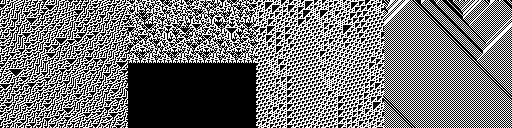

In [6]:
rules_1d = torch.tensor([30, 90, 110, 184], device=device)
ca1 = BinaryCA1D(device=device)
params_1d = {"rule": ((rules_1d[:, None] >> torch.arange(8, device=device)) & 1).float()}
x0_1d = ca1.seed(B=len(rules_1d), W=128, mode="noise")
rollout_1d = ca1.rollout(x0_1d, params_1d, steps=128)

rollout_1d.visualize()

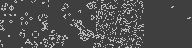

In [7]:
rules_2d = ["B3/S23", "B36/S23", "B2/S", "B3678/S34678"]
ca2 = OuterTotalisticCA2D(device=device)
params_list = [OuterTotalisticCA2D.from_desc(rule, B=1, device=device) for rule in rules_2d]
params_2d = {key: torch.cat([p[key] for p in params_list], dim=0) for key in ("B", "S")}
x0_2d = ca2.seed(B=len(rules_2d), H=48, W=48, mode="noise", p=0.25)
rollout_2d = ca2.rollout(x0_2d, params_2d, steps=96, every=2)

rollout_2d.visualize(t=-1)

In [8]:
df = pd.concat(
    [
        metric_table("BinaryCA1D", rollout_1d, [f"rule {int(r)}" for r in rules_1d]),
        metric_table("OuterTotalisticCA2D", rollout_2d, rules_2d),
    ],
    ignore_index=True,
)
df

,system,label,entropy_time,entropy_space,entropy_both,compression,mutual_info_time,mutual_info_space,time_regression
0,BinaryCA1D,rule 30,0.994170,0.994812,0.999991,1.005859,0.006475,0.006953,0.0
1,BinaryCA1D,rule 90,0.805240,0.484580,0.809143,0.360840,0.084438,0.013489,0.0
2,BinaryCA1D,rule 110,0.946532,0.982692,0.986978,0.737793,0.047222,0.021300,0.0
3,BinaryCA1D,rule 184,0.998488,0.999824,0.999824,0.167480,0.677917,0.710672,0.0
4,OuterTotalisticCA2D,B3/S23,0.473216,0.555276,0.559642,0.587674,0.060232,0.082889,0.0
5,OuterTotalisticCA2D,B36/S23,0.543669,0.604036,0.613498,0.671875,0.048320,0.053009,0.0
6,OuterTotalisticCA2D,B2/S,0.727288,0.744090,0.744440,0.946470,0.017614,0.002277,0.0
7,OuterTotalisticCA2D,B3678/S34678,0.175027,0.237652,0.269700,0.215350,0.036552,0.070056,0.0


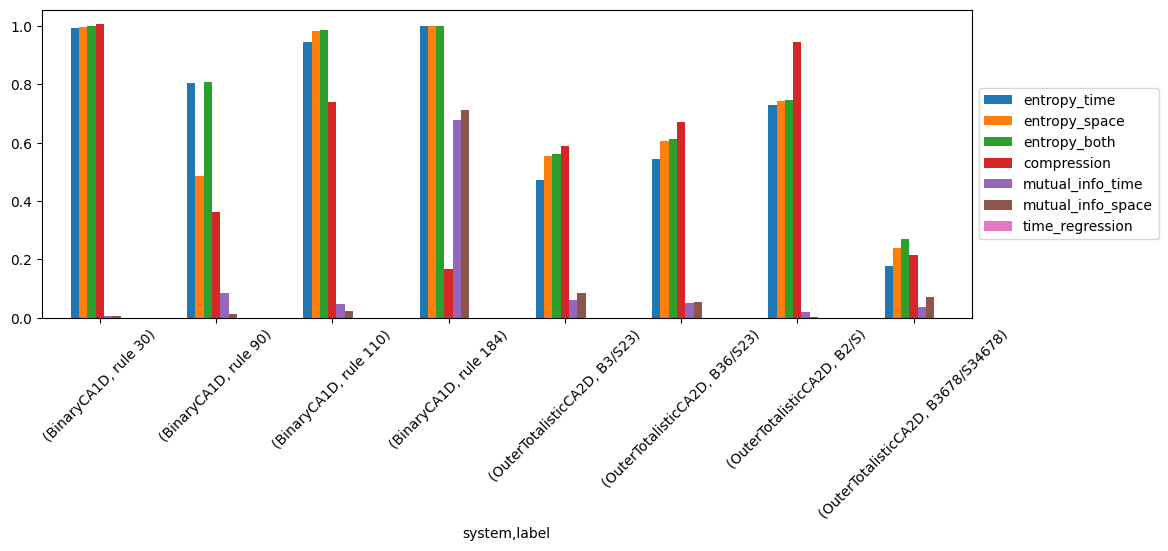

In [9]:
ax = df.set_index(["system", "label"]).plot.bar(figsize=(12, 4), rot=45)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5));